# Neural networks and automatic differentiation in PyTorch

Author: Filippo Masi


This notebook illustrates, on a one-dimensional regression problem, the main ingredients used throughout the course:

1. generate a noisy training dataset;
2. define a multilayer perceptron (MLP);
3. train the network by minimizing a mean-squared error;
4. evaluate the learned function;
5. differentiate the trained network with automatic differentiation (AD);
6. compare the learned first and second derivatives with the analytical derivatives.

We use the target function

$$
y(x)=\sin(\pi x), \qquad x\in[-1,1].
$$

The neural network approximation is denoted by $f_\theta(x)$, where $\theta$ collects all trainable weights and biases.


## 1. Setup and dataset

We first import PyTorch and Matplotlib, select the available device, and generate the data.

The training observations are noisy:

$$
y_i = \sin(\pi x_i) + \varepsilon_i,
$$

whereas the test values are evaluated from the exact target function. A fixed random seed makes the example reproducible.


In [1]:
import torch
from torch import nn
from torch.func import jacfwd, jacrev, vmap
import matplotlib.pyplot as plt

torch.set_default_dtype(torch.float64)
torch.manual_seed(7)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device: {device}")


def target(x: torch.Tensor) -> torch.Tensor:
    """Exact function used to generate the data."""
    return torch.sin(torch.pi * x)


# Training data: N noisy observations in [-1, 1].
N = 80
x_train = 2.0 * torch.rand(N, 1, device=device) - 1.0
y_clean = target(x_train)
y_train = y_clean + 0.05 * torch.randn_like(y_clean)

# Dense, noise-free grid used for evaluation.
x_test = torch.linspace(-1.0, 1.0, 400, device=device).unsqueeze(1)
y_test = target(x_test)


device: cpu


The plot below shows the noisy dataset $\mathcal D_{XY}$ together with the exact function that generated it.


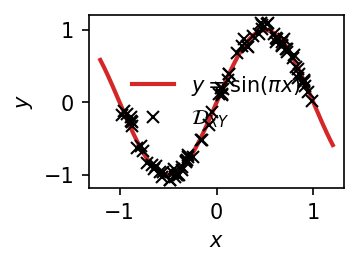

In [2]:
x_plot = torch.linspace(-1.2, 1.2, 200)

fig, ax = plt.subplots(1, dpi=150, figsize=(2.2,1.5))
ax.plot(
    x_plot,
    target(x_plot),
    linewidth=2.0,
    color="tab:red",
    label=r"$y=\sin(\pi x)$",
)
ax.plot(
    x_train.detach().cpu(),
    y_train.detach().cpu(),
    linestyle="none",
    marker="x",
    color="black",
    label=r"$\mathcal{D}_{XY}$",
)
ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$y$")
ax.legend(framealpha=0.0)
plt.show()


## 2. Define and train a multilayer perceptron

We use a fully connected neural network with two hidden layers:

$$
1 \longrightarrow 32 \longrightarrow 32 \longrightarrow 1,
$$

with the hyperbolic tangent activation in the hidden layers.

The parameters are fitted by minimizing the empirical mean-squared error

$$
L_{\mathcal D}(\theta)
=
\frac{1}{N}\sum_{i=1}^N
\left(f_\theta(x_i)-y_i\right)^2.
$$

PyTorch computes $\nabla_\theta L_{\mathcal D}$ by reverse-mode automatic differentiation when `loss.backward()` is called. Adam then uses this gradient to update the parameters.


In [3]:
model = nn.Sequential(
    nn.Linear(1, 32),
    nn.Tanh(),
    nn.Linear(32, 32),
    nn.Tanh(),
    nn.Linear(32, 1),
).to(device)

loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1.0e-3)

n_steps = 2_000
history: list[float] = []

model.train()

for step in range(n_steps):
    # Remove gradients accumulated during the previous iteration.
    optimizer.zero_grad(set_to_none=True)

    # Forward pass: evaluate f_theta(x_i).
    prediction = model(x_train)

    # Scalar empirical loss.
    loss = loss_fn(prediction, y_train)

    # Reverse-mode AD: compute gradients with respect to all parameters.
    loss.backward()

    # Adam parameter update.
    optimizer.step()

    history.append(loss.item())


# Evaluate the trained model on a dense test grid.
model.eval()
with torch.no_grad():
    y_test_pred = model(x_test)
    rmse = torch.sqrt(loss_fn(y_test_pred, y_test))

n_parameters = sum(p.numel() for p in model.parameters())

assert y_test_pred.shape == y_test.shape
assert torch.isfinite(rmse)

print(f"number of trainable parameters: {n_parameters}")
print(f"test RMSE: {rmse.item():.3e}")


number of trainable parameters: 1153
test RMSE: 2.359e-02


## 3. Training history

The loss should decrease as the optimizer fits the network parameters to the noisy observations.

The horizontal axis is the optimization step. Although the full dataset is used at every step here, the optimizer is Adam rather than plain stochastic gradient descent.


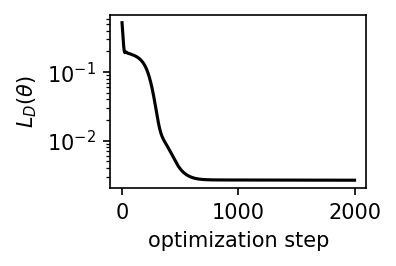

In [4]:
fig, ax = plt.subplots(1, dpi=150, figsize=(2.2,1.5))
ax.plot(history, linewidth=1.5, color="black")
ax.set_xlabel("optimization step")
ax.set_ylabel(r"$L_{ D}(\theta)$")
ax.set_yscale("log")
plt.show()


## 4. Differentiate the trained neural network

Once the network has been trained, it is itself a differentiable function of its input.

Let

$$
u(x) := f_\theta(x).
$$

We compute

$$
u_x(x)=\frac{\mathrm d u}{\mathrm d x},
\qquad
u_{xx}(x)=\frac{\mathrm d^2 u}{\mathrm d x^2}.
$$

Two PyTorch interfaces are shown below.

### Standard autograd interface

For a batch of input points, `torch.autograd.grad` computes the derivative of the network output with respect to the input. The option `create_graph=True` is important when higher-order derivatives will subsequently be needed.

### Functional transforms

For a function evaluated at a single point:

- `jacrev` computes its Jacobian using reverse-mode AD;
- `jacfwd` computes a Jacobian using forward-mode AD;
- `vmap` applies the resulting single-point operation efficiently over a batch.

In this one-dimensional example, the Jacobian is the first derivative and the Hessian contains the second derivative.


In [5]:
# Points at which input derivatives will be evaluated.
x_phys = torch.linspace(-1.0, 1.0, 200, device=device).unsqueeze(1)
x_phys.requires_grad_(True)

# Network values u(x) = f_theta(x).
u = model(x_phys)

# First derivative using the standard autograd interface.
#
# u.sum() produces a scalar whose derivative with respect to x_phys
# contains the pointwise derivatives because samples are independent.
#
# create_graph=True keeps the derivative computation differentiable,
# allowing higher-order derivatives to be formed later.
u_x = torch.autograd.grad(
    u.sum(),
    x_phys,
    create_graph=True,
)[0]


# Functional-transform version for a single input point.
def u_single(x: torch.Tensor) -> torch.Tensor:
    """Evaluate the trained scalar network at one input point."""
    return model(x).squeeze()


# Remove the graph attached to x_phys before using the functional transforms.
X = x_phys.detach()

# grad_u(x) = du/dx, represented here as a 1D Jacobian.
grad_u = jacrev(u_single)

# hess_u(x) = d/dx [du/dx].
hess_u = jacfwd(grad_u)

# Vectorize the single-point operations over all evaluation points.
u_value = vmap(u_single)(X)
u_x_func = vmap(grad_u)(X)
H = vmap(hess_u)(X)

# In one spatial dimension, the Hessian has a single entry.
u_xx = H[:, 0, 0]

# The two ways of evaluating the first derivative should agree.
torch.testing.assert_close(u_x.detach(), u_x_func)

print("u shape:    ", tuple(u_value.shape))
print("u_x shape:  ", tuple(u_x_func.shape))
print("u_xx shape: ", tuple(u_xx.shape))


u shape:     (200,)
u_x shape:   (200, 1)
u_xx shape:  (200,)


## 5. Learned function

The trained MLP should approximate the underlying function despite the noise in the training observations.

The comparison below uses the exact target only as a reference; the network was trained from the noisy samples.


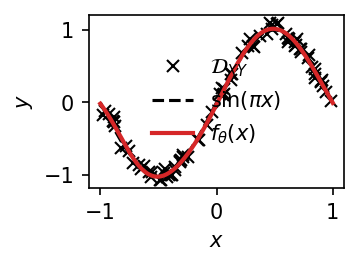

In [6]:
fig, ax = plt.subplots(1, dpi=150, figsize=(2.2,1.5))

ax.plot(
    x_train.detach().cpu(),
    y_train.detach().cpu(),
    linestyle="none",
    marker="x",
    color="black",
    label=r"$\mathcal{D}_{XY}$",
)
ax.plot(
    x_phys.detach().cpu(),
    target(x_phys.detach()).cpu(),
    linestyle="--",
    linewidth=1.5,
    color="black",
    label=r"$\sin(\pi x)$",
)
ax.plot(
    x_phys.detach().cpu(),
    u.detach().cpu(),
    linewidth=2.0,
    color="tab:red",
    label=r"$f_\theta(x)$",
)

ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$y$")
ax.legend(framealpha=0.0)
plt.show()


## 6. First derivative

For the exact target function,

$$
\frac{\mathrm d}{\mathrm d x}\sin(\pi x)
=
\pi\cos(\pi x).
$$

We compare this analytical derivative with the derivative of the trained neural network obtained by AD.

Notice that fitting function values does not explicitly guarantee an exact fit of their derivatives. The quality of $f'_\theta$ therefore depends on the learned approximation.


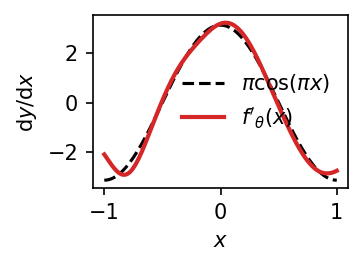

In [7]:
exact_first_derivative = torch.pi * torch.cos(torch.pi * x_phys.detach())

fig, ax = plt.subplots(1, dpi=150, figsize=(2.2,1.5))
ax.plot(
    x_phys.detach().cpu(),
    exact_first_derivative.cpu(),
    linestyle="--",
    linewidth=1.5,
    color="black",
    label=r"$\pi\cos(\pi x)$",
)
ax.plot(
    x_phys.detach().cpu(),
    u_x.detach().cpu(),
    linewidth=2.0,
    color="tab:red",
    label=r"$f'_\theta(x)$",
)
ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$\mathrm{d}y/\mathrm{d}x$")
ax.legend(framealpha=0.0)
plt.show()


## 7. Second derivative

Differentiating once more gives

$$
\frac{\mathrm d^2}{\mathrm d x^2}\sin(\pi x)
=
-\pi^2\sin(\pi x).
$$

The second derivative is obtained by differentiating the first derivative. This is an example of higher-order automatic differentiation, which is especially useful in scientific machine learning when differential operators appear in the loss function.


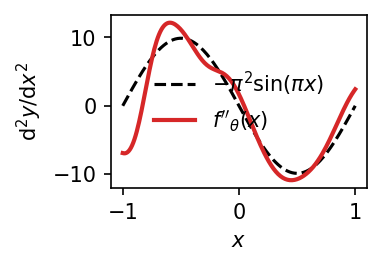

In [8]:
exact_second_derivative = -(torch.pi**2) * torch.sin(torch.pi * x_phys.detach())

fig, ax = plt.subplots(1, dpi=150, figsize=(2.2,1.5))
ax.plot(
    x_phys.detach().cpu(),
    exact_second_derivative.cpu(),
    linestyle="--",
    linewidth=1.5,
    color="black",
    label=r"$-\pi^2\sin(\pi x)$",
)
ax.plot(
    x_phys.detach().cpu(),
    u_xx.detach().cpu(),
    linewidth=2.0,
    color="tab:red",
    label=r"$f''_\theta(x)$",
)
ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$\mathrm{d}^2y/\mathrm{d}x^2$")
ax.legend(framealpha=0.0)
plt.show()


## 8. Takeaways

This example connects the main computational ingredients used later in the course:

- an MLP represents a trainable function $f_\theta$;
- optimization selects $\theta$ by minimizing an empirical loss;
- reverse-mode AD computes parameter gradients during training;
- AD can also differentiate the trained model with respect to its inputs;
- `jacrev`, `jacfwd`, and `vmap` provide composable tools for Jacobians, Hessians, and batched derivative evaluation;
- higher-order input derivatives are available without finite-difference approximations.